In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

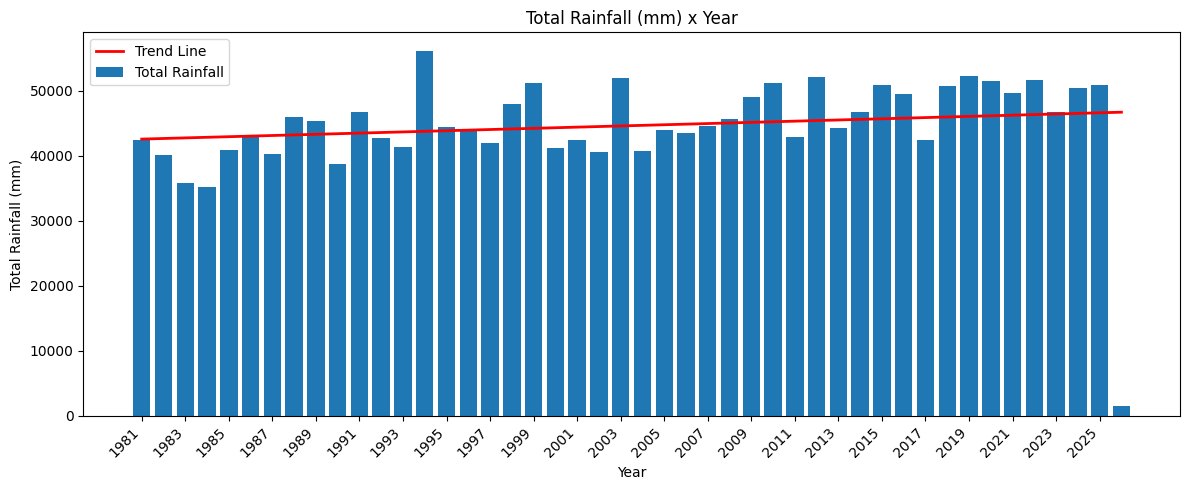

In [16]:
df = pd.read_csv('Data/bfa-rainfall-subnat-full.csv')
df['time'] = pd.to_datetime(df['date'])
df = df.sort_values('time')
yearly_total = df.groupby(df['time'].dt.year)['rfh'].sum()

plt.figure(figsize=(12, 5))
plt.bar(yearly_total.index.astype(str), yearly_total, label='Total Rainfall')

# Calculate and plot trend line
z = np.polyfit(yearly_total.index, yearly_total.values, 1)
p = np.poly1d(z)
plt.plot(yearly_total.index.astype(str), p(yearly_total.index), color='red', linewidth=2, label='Trend Line')

plt.xlabel('Year')
plt.ylabel('Total Rainfall (mm)')
plt.title('Total Rainfall (mm) x Year')
plt.xticks(yearly_total.index[::2].astype(str), rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

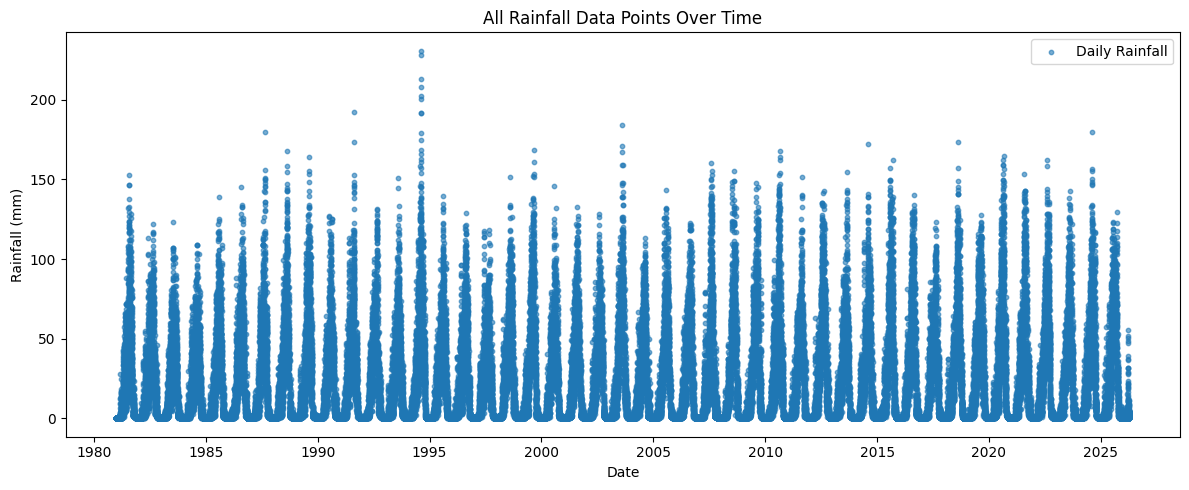

In [17]:
# Plot every rainfall datapoint (not aggregated by year)
plt.figure(figsize=(12, 5))
plt.scatter(df['time'], df['rfh'], s=10, alpha=0.6, label='Daily Rainfall')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.title('All Rainfall Data Points Over Time')
plt.legend()
plt.tight_layout()
plt.show()

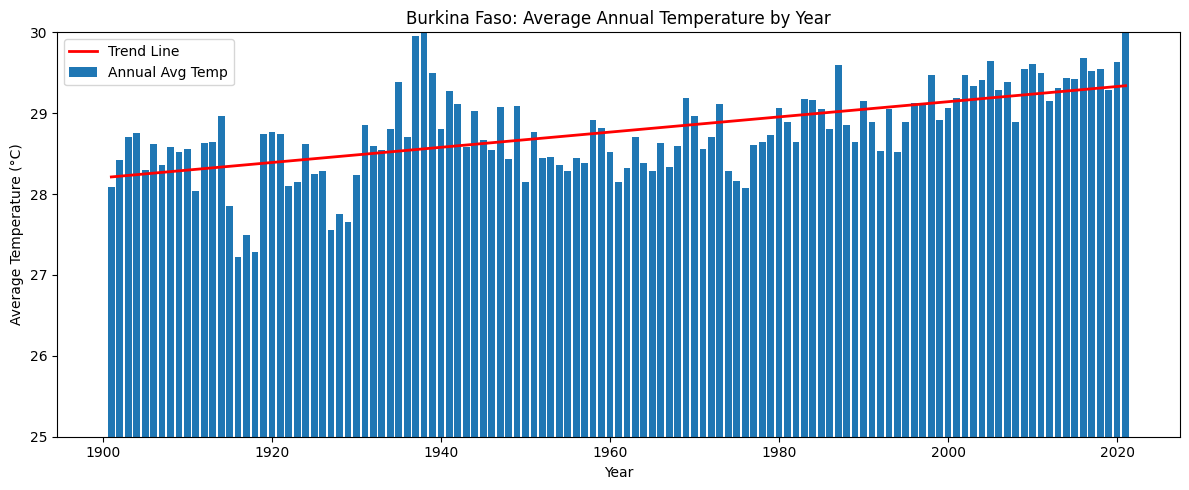

In [14]:
df = pd.read_csv('Data/burkina-faso-tas_timeseries_annual_cru_1901-2021_bfa.csv', skiprows=1)
# The first column is the year, the second is the national average
df.columns.values[0] = 'Year'
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])

plt.figure(figsize=(12,5))
plt.bar(df['Year'], df['Burkina Faso'], label='Annual Avg Temp')

# Calculate and plot trend line
z = np.polyfit(df['Year'], df['Burkina Faso'], 1)
p = np.poly1d(z)
plt.plot(df['Year'], p(df['Year']), color='red', linewidth=2, label='Trend Line')

plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')
plt.title('Burkina Faso: Average Annual Temperature by Year')
plt.ylim(25, 30)
plt.legend()
plt.tight_layout()
plt.show()